In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_PATH = r"D:\Python_For_DataScience\Stat\assignment\nepal_student_performance.csv"
df = pd.read_csv(FILE_PATH)

fi = df["family_income"].dropna()   # missing values removed for the calculations
es = df["exam_score"].dropna()
print("family_income n =", len(fi), "| exam_score n =", len(es))

family_income n = 1200 | exam_score n = 1200


In [ ]:
# ================= CLEANING PART =================

# 1. keep the raw (with missing values) as a backup
df.to_csv("nepal_student_performance_raw.csv", index=False)

# 2. fill numeric columns with the MEDIAN
df_clean = df.copy()
for col in ["study_hours", "sleep_hours", "attendance_pct", "family_income"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 3. fill categorical columns with the MOST COMMON value
for col in ["location_type", "has_tuition"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# 4. save the clean data (same file name, now with NO missing values)
df_clean.to_csv("nepal_student_performance.csv", index=False)

# 5. check
print("Missing values left:", df_clean.isna().sum().sum())   # 0
print("Shape:", df_clean.shape)                               # (1200, 11)
print(pd.read_csv("nepal_student_performance.csv").isna().sum().sum())  # 0 in the saved file

In [7]:
def summary(s, name):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    print(f"--- {name} ---")
    print("Mean   :", round(s.mean(), 2))
    print("Median :", round(s.median(), 2))
    print("Std    :", round(s.std(), 2))
    print("IQR    :", round(q3 - q1, 2), f"(Q1={q1}, Q3={q3})")
    print("Skew   :", round(s.skew(), 2))
    print("Mean > Median?", s.mean() > s.median(), "| Skew > 0?", s.skew() > 0)
    print()

summary(fi, "family_income")
summary(es, "exam_score")

--- family_income ---
Mean   : 45.74
Median : 37.1
Std    : 52.95
IQR    : 26.52 (Q1=26.2, Q3=52.725)
Skew   : 12.76
Mean > Median? True | Skew > 0? True

--- exam_score ---
Mean   : 53.12
Median : 51.5
Std    : 13.73
IQR    : 17.62 (Q1=43.875, Q3=61.5)
Skew   : 0.53
Mean > Median? True | Skew > 0? True



In [8]:
def hand_std(s, name):
    x = s.head(10).reset_index(drop=True)
    mean = x.mean()
    table = pd.DataFrame({"x": x, "x - mean": (x - mean).round(3),
                          "(x - mean)^2": ((x - mean) ** 2).round(3)})
    ssd = ((x - mean) ** 2).sum()
    variance = ssd / (len(x) - 1)
    print(f"--- {name} (first 10 non-missing rows) ---")
    print(table)
    print("Mean                     :", round(mean, 3))
    print("Sum of squared deviations:", round(ssd, 3))
    print("Variance (SSD / (n-1))   :", round(variance, 3))
    print("Std by hand (sqrt)       :", round(variance ** 0.5, 3))
    print("Std from .std()          :", round(x.std(), 3))
    print("Match?", np.isclose(variance ** 0.5, x.std()))
    print()

hand_std(es, "exam_score")
hand_std(fi, "family_income")

--- exam_score (first 10 non-missing rows) ---
      x  x - mean  (x - mean)^2
0  42.3     -6.37        40.577
1  60.3     11.63       135.257
2  33.6    -15.07       227.105
3  68.6     19.93       397.205
4  50.3      1.63         2.657
5  50.4      1.73         2.993
6  47.5     -1.17         1.369
7  47.7     -0.97         0.941
8  50.3      1.63         2.657
9  35.7    -12.97       168.221
Mean                     : 48.67
Sum of squared deviations: 978.981
Variance (SSD / (n-1))   : 108.776
Std by hand (sqrt)       : 10.43
Std from .std()          : 10.43
Match? True

--- family_income (first 10 non-missing rows) ---
       x  x - mean  (x - mean)^2
0   18.6    -32.42      1051.056
1   32.9    -18.12       328.334
2   54.8      3.78        14.288
3   61.1     10.08       101.606
4   37.1    -13.92       193.766
5   39.0    -12.02       144.480
6   37.1    -13.92       193.766
7   22.6    -28.42       807.696
8   37.1    -13.92       193.766
9  169.9    118.88     14132.454
Mean  

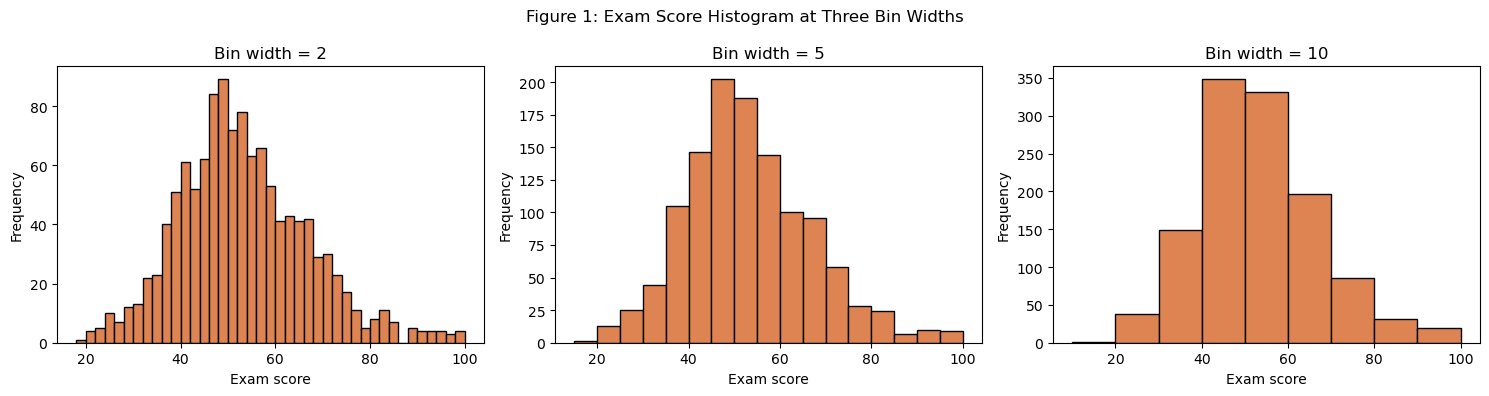

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, w in zip(axes, [2, 5, 10]):
    bins = np.arange(es.min() // w * w, es.max() + w, w)
    ax.hist(es, bins=bins, edgecolor="black", color="#DD8452")
    ax.set_title(f"Bin width = {w}")
    ax.set_xlabel("Exam score")
    ax.set_ylabel("Frequency")
fig.suptitle("Figure 1: Exam Score Histogram at Three Bin Widths")
plt.tight_layout()
plt.show()

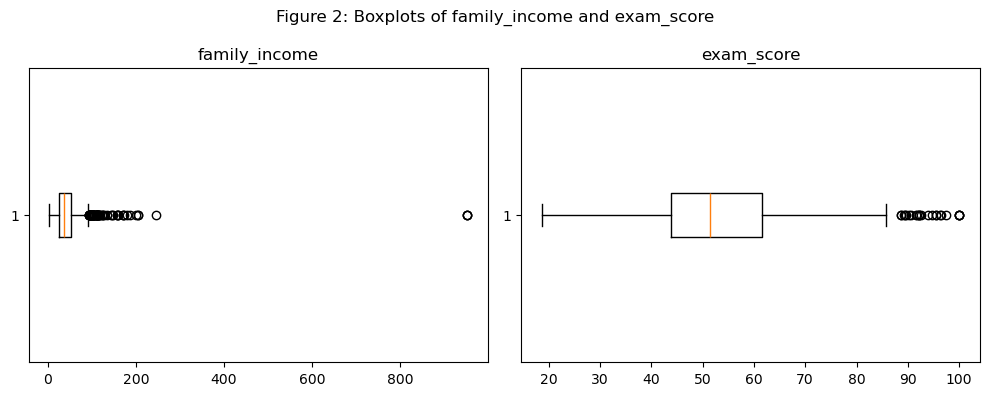

--- family_income ---
Q1=26.2, Q3=52.725, IQR=26.52
Lower fence = -13.59, Upper fence = 92.51
Number of outliers: 73
--- exam_score ---
Q1=43.875, Q3=61.5, IQR=17.62
Lower fence = 17.44, Upper fence = 87.94
Number of outliers: 24
      student_id  family_income
596          597          187.5
264          265          200.6
665          666          204.5
758          759          205.1
326          327          244.8
937          938          950.0
748          749          950.0
1160        1161          950.0
      student_id  exam_score
116          117        95.5
850          851        96.2
1090        1091        96.4
656          657        97.4
630          631       100.0
640          641       100.0
109          110       100.0
427          428       100.0


In [10]:
def outliers(s, name):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = df.loc[(df[name] < lo) | (df[name] > hi), ["student_id", name]]
    print(f"--- {name} ---")
    print(f"Q1={q1}, Q3={q3}, IQR={round(iqr, 2)}")
    print(f"Lower fence = {round(lo, 2)}, Upper fence = {round(hi, 2)}")
    print("Number of outliers:", len(out))
    return out

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(fi, vert=False); axes[0].set_title("family_income")
axes[1].boxplot(es, vert=False); axes[1].set_title("exam_score")
fig.suptitle("Figure 2: Boxplots of family_income and exam_score")
plt.tight_layout(); plt.show()

out_fi = outliers(fi, "family_income")
out_es = outliers(es, "exam_score")
print(out_fi.sort_values("family_income").tail(8))
print(out_es.sort_values("exam_score").tail(8))

In [11]:
def zcheck(s, name):
    z = (s - s.mean()) / s.std()
    print(f"--- {name} ---")
    for k, expected in [(1, 68), (2, 95), (3, 99.7)]:
        print(f"Within {k} SD: {(z.abs() <= k).mean() * 100:.2f}%  (normal: {expected}%)")
    print()
    return z

z_es = zcheck(es, "exam_score")
z_fi = zcheck(fi, "family_income")
print(z_es.head())

--- exam_score ---
Within 1 SD: 70.92%  (normal: 68%)
Within 2 SD: 94.50%  (normal: 95%)
Within 3 SD: 99.17%  (normal: 99.7%)

--- family_income ---
Within 1 SD: 95.08%  (normal: 68%)
Within 2 SD: 98.67%  (normal: 95%)
Within 3 SD: 99.58%  (normal: 99.7%)

0   -0.788437
1    0.522701
2   -1.422153
3    1.127281
4   -0.205709
Name: exam_score, dtype: float64


C:\Users\LOQ\AppData\Local\Temp\ipykernel_10436\2525407602.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=groups)


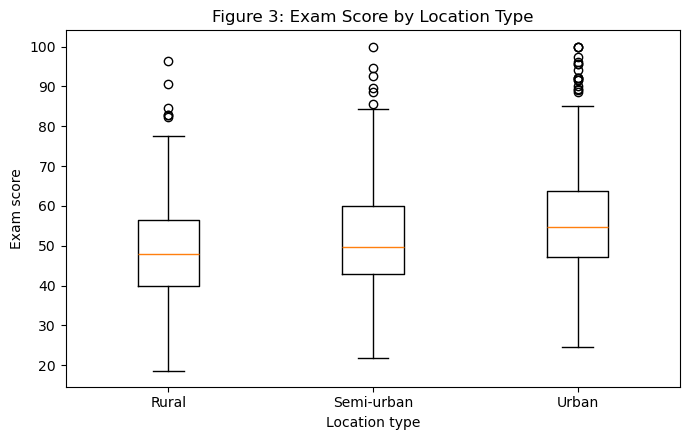

               count   mean  median    std
location_type                             
Rural            298  49.18   47.95  13.50
Semi-urban       353  51.95   49.70  13.42
Urban            549  56.01   54.70  13.42


In [12]:
groups = ["Rural", "Semi-urban", "Urban"]
data = [df.loc[df["location_type"] == g, "exam_score"].dropna() for g in groups]

plt.figure(figsize=(7, 4.5))
plt.boxplot(data, labels=groups)
plt.title("Figure 3: Exam Score by Location Type")
plt.xlabel("Location type")
plt.ylabel("Exam score")
plt.tight_layout()
plt.show()

print(df.groupby("location_type")["exam_score"].agg(["count", "mean", "median", "std"]).round(2))